In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
from pandas import DataFrame
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import math
import os

plt.rcParams['figure.dpi'] = 150

In [4]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

has_weights = 1 # 0 = no, unreweighted data; 1 = yes, reweighted data

nsim = 10 # number of simulations

In [5]:
# Weights (unphos)

if has_weights ==1:
    ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)
    p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [6]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [7]:
ctd = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/radgyr/radgyr_a_ctd.dat', sep = r'\s+')
ctd = ctd.drop(['1-23[Max]'],axis=1)

In [6]:
ctd.head()

,#Frame,1-23
0,1,10.3291
1,2,10.2979
2,3,10.3115
3,4,10.3441
4,5,10.3761


In [8]:
ctd_p = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/radgyr/radgyr_a_ctd_p.dat', sep = r'\s+')
ctd_p = ctd_p.drop(['1-23[Max]'],axis=1)

In [8]:
pmean = np.average(ctd_p["1-23"], weights=p_ctd_weights_combined[0])
npmean = np.average(ctd["1-23"], weights=ctd_weights_combined[0])

pstd = np.sqrt(np.cov(ctd_p["1-23"], aweights=p_ctd_weights_combined[0]))
npstd = np.sqrt(np.cov(ctd["1-23"], aweights=ctd_weights_combined[0]))

print("npmean: {}".format(npmean))
print("npstd: {}".format(npstd))
print("pmean: {}".format(pmean))
print("pstd: {}".format(pstd))

# ctd_p

npmean: 10.173773845113283
npstd: 1.9429965616530633
pmean: 11.230482067419086
pstd: 1.9891505256868884


In [9]:
# ctd_p



phosphoryalted vs unphosphorylated

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


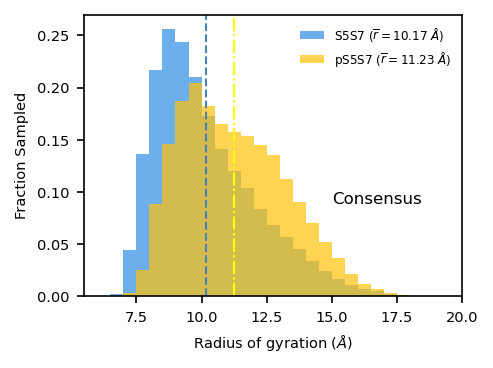

In [23]:
plt.figure()

binedges = np.arange(6,20,0.5)

plt.hist(ctd['1-23'], bins = binedges, weights = ctd_weights_combined[0], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(npmean, 2)), alpha=0.6)
plt.hist(ctd_p['1-23'], bins = binedges, weights = p_ctd_weights_combined[0], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean, 2)), alpha=0.7)

plt.axvline(npmean, color='steelblue', ls='--', linewidth=1)
plt.axvline(pmean, color='yellow', ls='-.', linewidth=1)
plt.ylim([0, 0.27])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Radius of gyration ($\AA$)', fontsize=7)
#plt.title('Radius of Gyration (Con)')
plt.legend(loc="upper right", fontsize=5.75, frameon=False)
plt.text(15, 0.1, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('radgyr_con.png', dpi=300, bbox_inches='tight')

plt.show()

In [24]:
pmean - npmean

1.0567082223058026

In [25]:
over_time_p = ctd_p.drop(columns=["#Frame"]) 
over_time = ctd.drop(columns=["#Frame"]) 

In [26]:
over_time_p

,1-23
0,10.8431
1,10.8517
2,10.8600
3,10.8703
4,10.8450
...,...
47999995,11.1583
47999996,11.1753
47999997,11.1411
47999998,11.1475


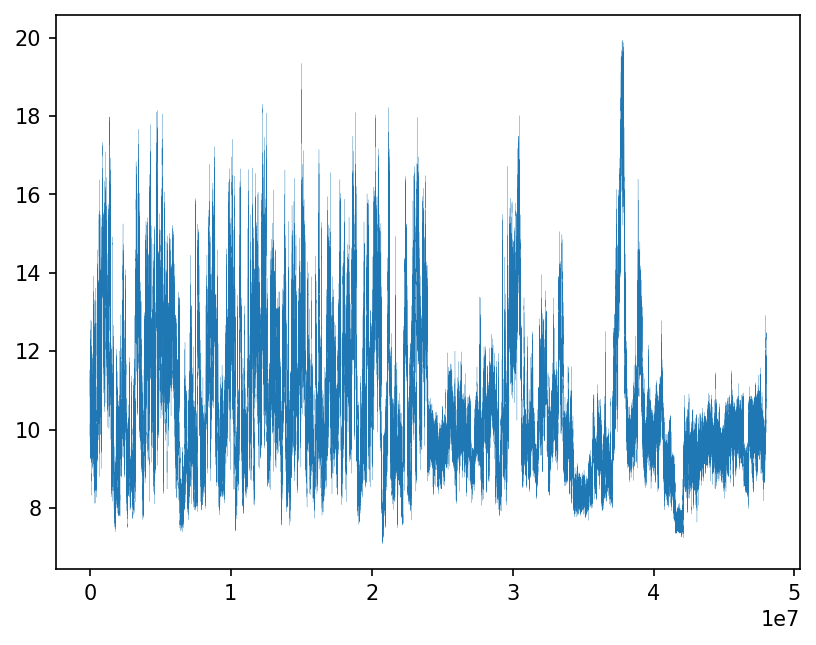

In [27]:
size = len(over_time_p.index)
plt.plot(over_time_p.index[:size], over_time_p["1-23"][:size],linewidth=0.1)


In [28]:
max_radgyr_p = max(over_time_p["1-23"][:100000])
min_radgyr_p = min(over_time_p["1-23"][:100000])

over_time_p.loc[(over_time_p["1-23"] == max_radgyr_p)]

,1-23
75045,12.8029
256965,12.8029
285697,12.8029
424035,12.8029
427961,12.8029
...,...
39048859,12.8029
39068874,12.8029
39096193,12.8029
39104609,12.8029


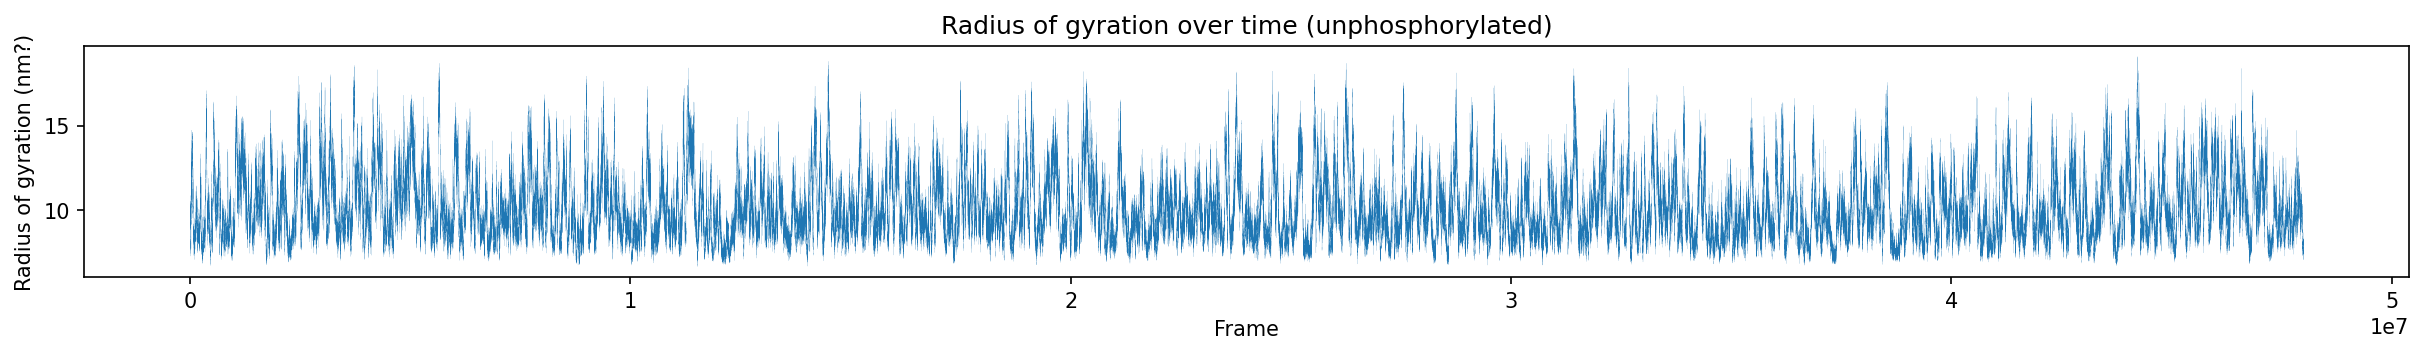

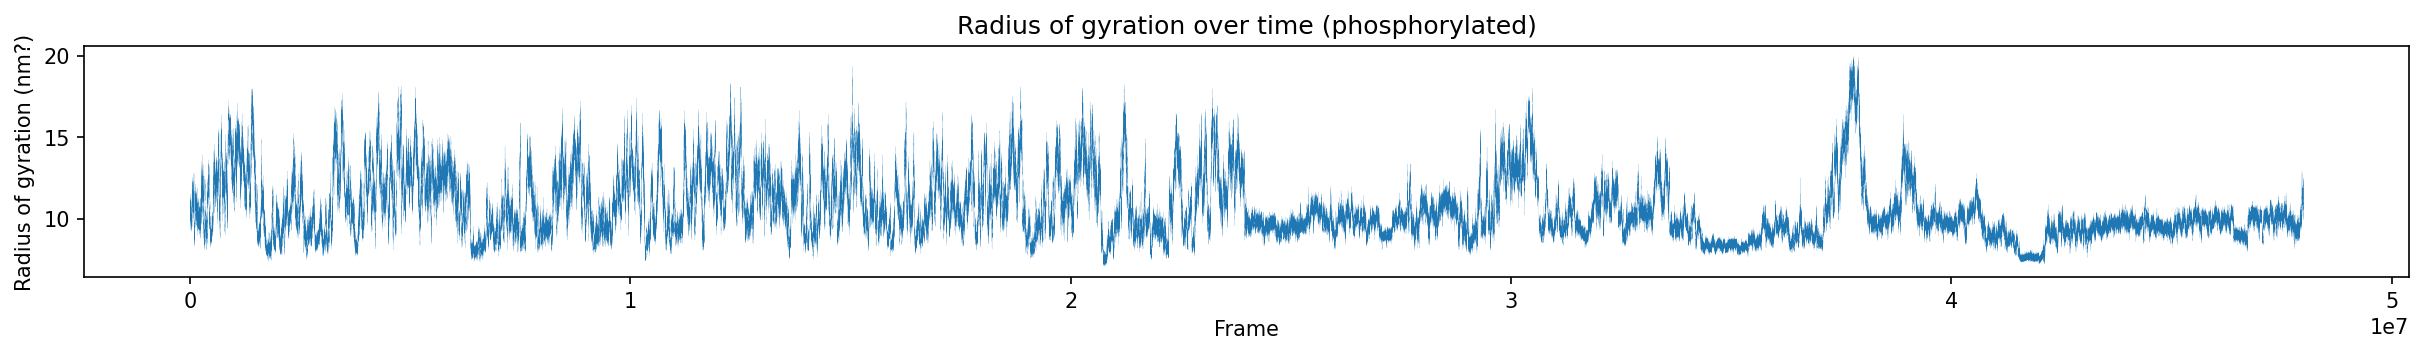

In [29]:
size = len(over_time.index)
size_p = len(over_time_p.index)

fig = plt.figure(figsize=(20, 2))
ax = fig.add_subplot(111)
ax.plot(over_time.index[:size], over_time["1-23"][:size], linewidth=0.05)
plt.title('Radius of gyration over time (unphosphorylated)')
plt.xlabel('Frame')
plt.ylabel('Radius of gyration (nm?)')
ax


fig = plt.figure(figsize=(20, 2))
ax = fig.add_subplot(111)
ax.plot(over_time.index[:size], over_time_p["1-23"][:size], linewidth=0.05)
plt.title('Radius of gyration over time (phosphorylated)')
plt.xlabel('Frame')
plt.ylabel('Radius of gyration (nm?)')
ax
plt.show()

# Turn vs no turn

In [30]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

ctd_secstruc = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/turn/ctd_sec.out', **params)
ctd_phos_secstruc = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_p_sec.out', **params)

In [31]:
ctd

,#Frame,1-23
0,1,10.3291
1,2,10.2979
2,3,10.3115
3,4,10.3441
4,5,10.3761
...,...,...
47999995,47999996,8.3214
47999996,47999997,8.3327
47999997,47999998,8.3472
47999998,47999999,8.3265


In [32]:
ctd['Pro13 secstruc'] = ctd_secstruc['PRO:14']

In [25]:
ctd['weights'] = ctd_weights_combined[0]

In [34]:
ctd

,#Frame,1-23,Pro13 secstruc,weights
0,1,10.3291,S,2.068308e-08
1,2,10.2979,T,8.310223e-09
2,3,10.3115,S,1.665468e-08
3,4,10.3441,S,4.747710e-08
4,5,10.3761,S,1.088663e-08
...,...,...,...,...
47999995,47999996,8.3214,0,1.861614e-08
47999996,47999997,8.3327,0,1.241771e-08
47999997,47999998,8.3472,0,1.139632e-08
47999998,47999999,8.3265,0,5.317541e-09


In [35]:
ctd_p['Pro13 secstruc'] = ctd_phos_secstruc['PRO:14']

In [24]:
ctd_p['weights'] = p_ctd_weights_combined[0]

In [37]:
ctd_w_turn = ctd[ctd['Pro13 secstruc'] == 'T']

In [38]:
ctd_w_turn['weights'] = ctd_w_turn['weights']/ctd_w_turn['weights'].sum()

/tmp/ipykernel_4041853/385076149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_w_turn['weights'] = ctd_w_turn['weights']/ctd_w_turn['weights'].sum()


In [39]:
ctd_p_w_turn = ctd_p[ctd_p['Pro13 secstruc'] == 'T']

In [40]:
ctd_p_w_turn['weights'] = ctd_p_w_turn['weights']/ctd_p_w_turn['weights'].sum()

/tmp/ipykernel_4041853/67018472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_p_w_turn['weights'] = ctd_p_w_turn['weights']/ctd_p_w_turn['weights'].sum()


In [41]:
pmean_w_turn = np.average(ctd_p_w_turn["1-23"], weights=ctd_p_w_turn['weights'])
npmean_w_turn = np.average(ctd_w_turn["1-23"], weights=ctd_w_turn['weights'])

pstd_w_turn = np.sqrt(np.cov(ctd_p_w_turn["1-23"], aweights=ctd_p_w_turn['weights']))
npstd_w_turn = np.sqrt(np.cov(ctd_w_turn["1-23"], aweights=ctd_w_turn['weights']))

print("npmean: {}".format(npmean_w_turn))
print("npstd: {}".format(npstd_w_turn))
print("pmean: {}".format(pmean_w_turn))
print("pstd: {}".format(pstd_w_turn))


npmean: 9.526419465244803
npstd: 1.4720783481976591
pmean: 10.21996862544546
pstd: 1.6111651218804264


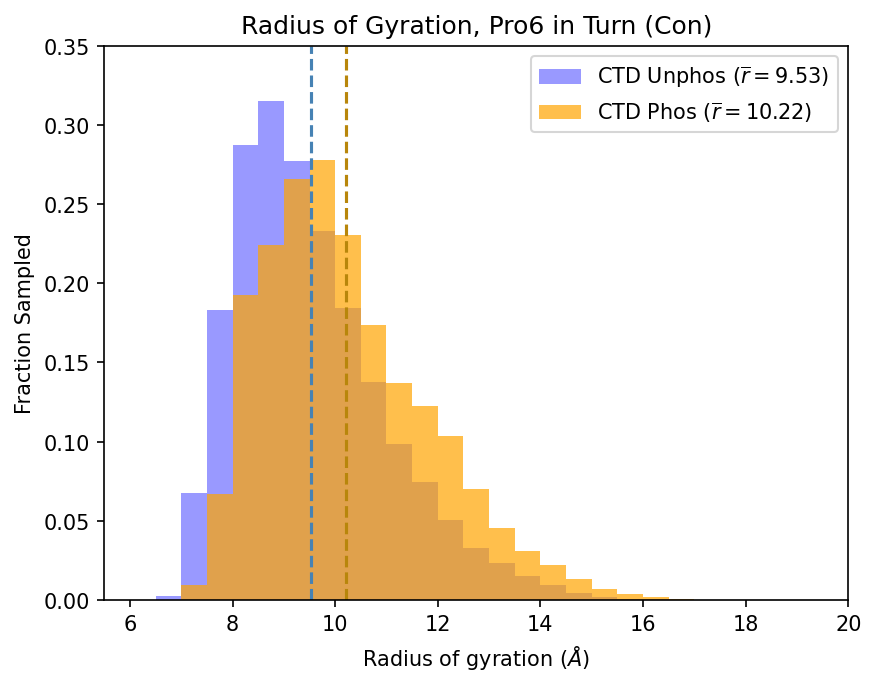

In [42]:
binedges = np.arange(6,20,0.5)

plt.hist(ctd_w_turn["1-23"], bins = binedges, weights = ctd_w_turn['weights'], density=True , color="blue", label=r"CTD Unphos ($\overline{r} = $"+"{})".format(round(npmean_w_turn, 2)), alpha=0.4)
plt.hist(ctd_p_w_turn["1-23"], bins = binedges, weights = ctd_p_w_turn['weights'], density=True , color="orange", label=r"CTD Phos ($\overline{r} = $"+"{})".format(round(pmean_w_turn, 2)), alpha=0.7)

plt.axvline(npmean_w_turn, color='steelblue', ls='--')
plt.axvline(pmean_w_turn, color='darkgoldenrod', ls='--')
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Radius of gyration ($\AA$)')
plt.title('Radius of Gyration, Pro6 in Turn (Con)')
plt.legend(loc="upper right", fontsize=10)
plt.show()
# filename = "radgyr_asn_1.pdf"
# path="/home/wbarr/data/ctd_project/Figure_July_2023/"    # remember to have a trailing '/' !!!!

# overwrite = False

# if not overwrite and os.path.exists(path + filename):
#     raise FileExistsError("File already exists and overwrite is set to False.")
# else:
#     plt.savefig(path + filename, format="pdf", bbox_inches="tight")
#     plt.show()
#     print("File Saved.")

In [43]:
ctd_wo_turn = ctd[ctd['Pro13 secstruc'] != 'T']

In [44]:
ctd_wo_turn['weights'] = ctd_wo_turn['weights']/ctd_wo_turn['weights'].sum()

/tmp/ipykernel_4041853/121632409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_wo_turn['weights'] = ctd_wo_turn['weights']/ctd_wo_turn['weights'].sum()


In [45]:
ctd_p_wo_turn = ctd_p[ctd_p['Pro13 secstruc'] != 'T']

In [46]:
ctd_p_wo_turn['weights'] = ctd_p_wo_turn['weights']/ctd_p_wo_turn['weights'].sum()

/tmp/ipykernel_4041853/129144290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_p_wo_turn['weights'] = ctd_p_wo_turn['weights']/ctd_p_wo_turn['weights'].sum()


In [47]:
pmean_wo_turn = np.average(ctd_p_wo_turn["1-23"], weights=ctd_p_wo_turn['weights'])
npmean_wo_turn = np.average(ctd_wo_turn["1-23"], weights=ctd_wo_turn['weights'])

pstd_wo_turn = np.sqrt(np.cov(ctd_p_wo_turn["1-23"], aweights=ctd_p_wo_turn['weights']))
npstd_wo_turn = np.sqrt(np.cov(ctd_wo_turn["1-23"], aweights=ctd_wo_turn['weights']))

print("npmean: {}".format(npmean_wo_turn))
print("npstd: {}".format(npstd_wo_turn))
print("pmean: {}".format(pmean_wo_turn))
print("pstd: {}".format(pstd_wo_turn))

npmean: 10.336171928264438
npstd: 2.011760090727534
pmean: 11.569700306695353
pstd: 1.9888927452891505


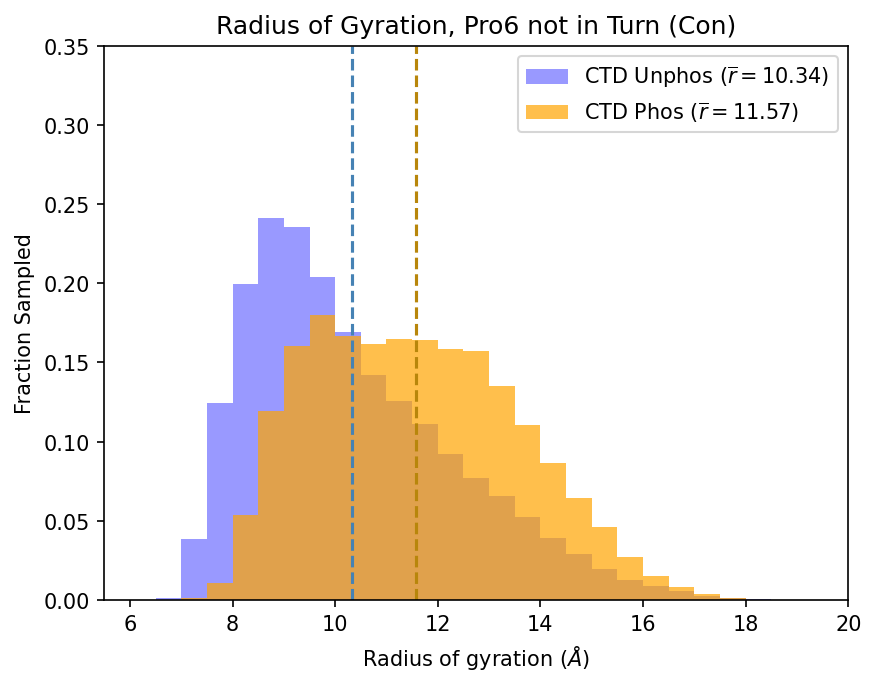

In [48]:
binedges = np.arange(6,20,0.5)

plt.hist(ctd_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_wo_turn['weights'], color="blue", label=r"CTD Unphos ($\overline{r} = $"+"{})".format(round(npmean_wo_turn, 2)), alpha=0.4)
plt.hist(ctd_p_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_p_wo_turn['weights'], color="orange", label=r"CTD Phos ($\overline{r} = $"+"{})".format(round(pmean_wo_turn, 2)), alpha=0.7)

plt.axvline(npmean_wo_turn, color='steelblue', ls='--')
plt.axvline(pmean_wo_turn, color='darkgoldenrod', ls='--')
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Radius of gyration ($\AA$)')
plt.title('Radius of Gyration, Pro6 not in Turn (Con)')
plt.legend(loc="upper right", fontsize=10)
plt.show()
# filename = "radgyr_asn_1.pdf"
# path="/home/wbarr/data/ctd_project/Figure_July_2023/"    # remember to have a trailing '/' !!!!

# overwrite = False

# if not overwrite and os.path.exists(path + filename):
#     raise FileExistsError("File already exists and overwrite is set to False.")
# else:
#     plt.savefig(path + filename, format="pdf", bbox_inches="tight")
#     plt.show()
#     print("File Saved.")

## Compare turn/no turn on same plot

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


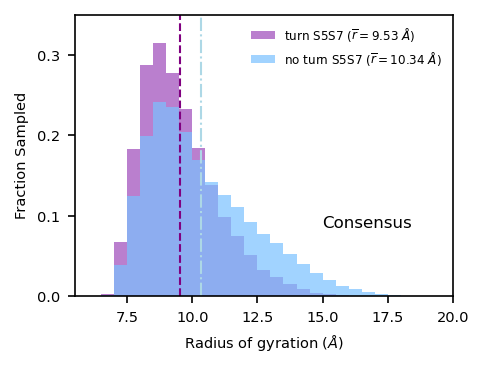

In [51]:
plt.figure()

binedges = np.arange(6,20,0.5)

plt.hist(ctd_w_turn["1-23"], bins = binedges, density=True , weights = ctd_w_turn['weights'], color="#77019E", label=r"turn S5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(npmean_w_turn, 2)), alpha=0.5)
plt.hist(ctd_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_wo_turn['weights'], color="#7AC1FF", label=r"no turn S5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(npmean_wo_turn, 2)), alpha=0.7)

plt.axvline(npmean_w_turn, color='purple', ls='--', linewidth=1)
plt.axvline(npmean_wo_turn, color='lightblue', ls='-.', linewidth=1)
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Radius of gyration ($\AA$)', fontsize=7)
#plt.title('Unphosphorylated (Con)')
plt.legend(loc="upper right", fontsize=5.75, frameon=False)
plt.text(15, 0.1, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('radgyr_con_turnnoturn.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


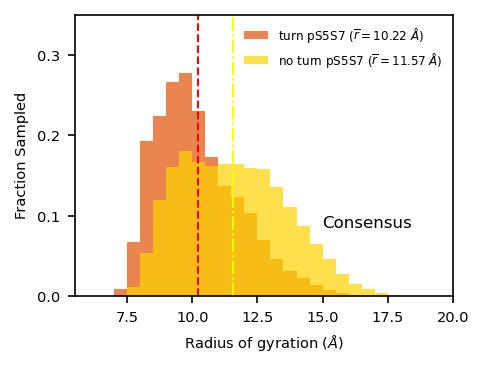

In [53]:
binedges = np.arange(6,20,0.5)

plt.figure()

plt.hist(ctd_p_w_turn["1-23"], bins = binedges, density=True , weights = ctd_p_w_turn['weights'], color="#E25105", label=r"turn pS5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_w_turn, 2)), alpha=0.7)
plt.hist(ctd_p_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_p_wo_turn['weights'], color="#FFD400", label=r"no turn pS5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_wo_turn, 2)), alpha=0.7)

plt.axvline(pmean_w_turn, color='red', ls='--', linewidth=1)
plt.axvline(pmean_wo_turn, color='yellow', ls='-.', linewidth=1)
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Radius of gyration ($\AA$)', fontsize=7)
#plt.title('Phosphorylated (Con)')
plt.legend(loc="upper right", fontsize=5.75, frameon=False)
plt.text(15, 0.1, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_radgyr_con_turnnoturn.png', dpi=300, bbox_inches='tight')

plt.show()

# Radgyr vs number of prolines in *cis*

In [132]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

In [133]:
ctd_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')

KeyboardInterrupt: 

In [10]:
df_360 = ctd_omega_angles_raw.copy()
# loop through columns to convert numbers below -90
for col in df_360:
    df_360.loc[df_360[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360[col] = round(df_360[col])  # Round angles to the nearest integer

In [11]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

In [12]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_omega_angles = df_360.copy()

In [13]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

temp_angles = ctd_omega_angles.copy()

ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_omega_angles[(ctd_omega_angles.iloc[:,1:] != "cis") & (ctd_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_4089134/3590104210.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
/tmp/ipykernel_4089134/3590104210.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [14]:
ctd_omega_angles.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,cis,trans,trans,trans,trans,trans,trans,cis,trans
1,2,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,cis,trans,trans,trans,trans,trans,trans,cis,trans
2,3,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,cis,trans,trans,trans,trans,trans,trans,cis,trans
3,4,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,cis,trans,trans,trans,trans,trans,trans,cis,trans
4,5,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,cis,trans,trans,trans,trans,trans,trans,cis,trans


In [15]:
ctd_num_cis = pd.DataFrame((ctd_omega_angles['omega:4'] == 'cis').astype(int) + (ctd_omega_angles['omega:7'] == 'cis').astype(int)
+ (ctd_omega_angles['omega:11'] == 'cis').astype(int) + (ctd_omega_angles['omega:14'] == 'cis').astype(int)
+ (ctd_omega_angles['omega:18'] == 'cis').astype(int) + (ctd_omega_angles['omega:21'] == 'cis').astype(int))

In [16]:
ctd_phos_num_cis = pd.DataFrame((ctd_phos_omega_angles['omega:4'] == 'cis').astype(int) + (ctd_phos_omega_angles['omega:7'] == 'cis').astype(int)
+ (ctd_phos_omega_angles['omega:11'] == 'cis').astype(int) + (ctd_phos_omega_angles['omega:14'] == 'cis').astype(int)
+ (ctd_phos_omega_angles['omega:18'] == 'cis').astype(int) + (ctd_phos_omega_angles['omega:21'] == 'cis').astype(int))

In [17]:
ctd_num_cis.head()

,0
0,2
1,2
2,2
3,2
4,2


In [18]:
ctd['num Pro in cis'] = ctd_num_cis[0]
ctd_p['num Pro in cis'] = ctd_phos_num_cis[0]

In [20]:
ctd_p

,#Frame,1-23,num Pro in cis
0,1,10.8431,2
1,2,10.8517,2
2,3,10.8600,2
3,4,10.8703,2
4,5,10.8450,2
...,...,...,...
47999995,47999996,11.1583,0
47999996,47999997,11.1753,0
47999997,47999998,11.1411,0
47999998,47999999,11.1475,0


In [ ]:
plt.figure()
plt.hist2d(ctd['num Pro in cis'], ctd['1-23'], weights = ctd['weights'], bins=[np.arange(-0.5, 7, 1), np.arange(6, 20, 0.5)])
plt.colorbar()
plt.xlabel("# of Prolines in cis")
plt.ylabel("Radius of gyration")
plt.title("Unphosphorylated")
plt.show()

In [ ]:
plt.figure()
plt.hist2d(ctd_p['num Pro in cis'], ctd_p['1-23'], weights = ctd_p['weights'], bins=[np.arange(-0.5, 7, 1), np.arange(6, 20, 0.5)])
plt.colorbar()
plt.xlabel("# of Prolines in cis")
plt.ylabel("Radius of gyration")
plt.title("Phosphorylated")
plt.show()

In [26]:
ctd_sim_list = np.array_split(ctd, nsim)
p_ctd_sim_list = np.array_split(ctd_p, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [27]:
# Define column names
columns = ['cis_0', 'cis_1', 'cis_2', 'cis_3', 'cis_4', 'cis_5', 'cis_6']

# Create an empty DataFrame with 2 rows and 5 columns
cis_radgyr = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [64]:
cis_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [65]:
i = 0
for sim in ctd_sim_list:
    
    cis_0_true = ((sim['num Pro in cis'] == 0)*sim['weights']).sum()
    cis_1_true = ((sim['num Pro in cis'] == 1)*sim['weights']).sum()
    cis_2_true = ((sim['num Pro in cis'] == 2)*sim['weights']).sum()
    cis_3_true = ((sim['num Pro in cis'] == 3)*sim['weights']).sum()
    cis_4_true = ((sim['num Pro in cis'] == 4)*sim['weights']).sum()
    cis_5_true = ((sim['num Pro in cis'] == 5)*sim['weights']).sum()
    cis_6_true = ((sim['num Pro in cis'] == 6)*sim['weights']).sum()

    mean = sim['1-23'].mul((sim['num Pro in cis'] == 0)*sim['weights'], 0).sum()/cis_0_true
    cis_radgyr.at[i, 'cis_0'] = mean
    cis_weights.at[i, 'cis_0'] = cis_0_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 1)*sim['weights'], 0).sum()/cis_1_true
    cis_radgyr.at[i, 'cis_1'] = mean
    cis_weights.at[i, 'cis_1'] = cis_1_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 2)*sim['weights'], 0).sum()/cis_2_true
    cis_radgyr.at[i, 'cis_2'] = mean
    cis_weights.at[i, 'cis_2'] = cis_2_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 3)*sim['weights'], 0).sum()/cis_3_true
    cis_radgyr.at[i, 'cis_3'] = mean
    cis_weights.at[i, 'cis_3'] = cis_3_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 4)*sim['weights'], 0).sum()/cis_4_true
    cis_radgyr.at[i, 'cis_4'] = mean
    cis_weights.at[i, 'cis_4'] = cis_4_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 5)*sim['weights'], 0).sum()/cis_5_true
    cis_radgyr.at[i, 'cis_5'] = mean
    cis_weights.at[i, 'cis_5'] = cis_5_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 6)*sim['weights'], 0).sum()/cis_6_true
    cis_radgyr.at[i, 'cis_6'] = mean
    cis_weights.at[i, 'cis_6'] = cis_6_true

    print("sim: ", i, cis_0_true, cis_1_true, cis_2_true, cis_3_true, cis_4_true, cis_5_true, cis_6_true)
    
    i += 1

/tmp/ipykernel_4089134/3584339566.py:27: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 5)*sim['weights'], 0).sum()/cis_5_true
/tmp/ipykernel_4089134/3584339566.py:30: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 6)*sim['weights'], 0).sum()/cis_6_true


sim:  0 0.060146626882526796 0.04385182736187122 0.013548204539934175 0.00156194369625884 3.804911816832876e-05 0.0 0.0
sim:  1 0.05557258406105163 0.04533728144138904 0.013835964301976512 0.002674732682943394 0.0005807998778097807 6.859448042276796e-05 3.231482704572301e-08
sim:  2 0.061053301434502265 0.04278256431658904 0.012354209185109908 0.002407360411855552 0.00013389953412756129 8.914333774341948e-09 0.0
sim:  3 0.05596108106999429 0.04528415515746421 0.014591931474720182 0.0026014199539477027 0.0002839434229485487 0.0 0.0
sim:  4 0.04909441310031148 0.04835113735998116 0.0183965336606662 0.0026490085184266324 0.00035609031252426286 4.590068605694907e-06 3.382144524831004e-08
sim:  5 0.04116797054351182 0.030689406137778392 0.008074413608059357 0.0013994099934535858 6.83908768133771e-05 1.1606779725188265e-08 0.0
sim:  6 0.03857118166804106 0.03146560579873431 0.010081824822387094 0.001032032282440856 0.00013177671826258117 0.0 0.0
sim:  7 0.03695342868040257 0.0312210525224732

In [66]:
weighted_mean_and_se(cis_radgyr.iloc[:,0].tolist(), cis_weights.iloc[:,0].tolist())

(10.368800692562958, 0.08939162589572633)

In [67]:
weighted_mean_and_se(cis_radgyr.iloc[:,1].tolist(), cis_weights.iloc[:,1].tolist())

(10.078603324092589, 0.11075185094376953)

In [68]:
weighted_mean_and_se(cis_radgyr.iloc[:,2].tolist(), cis_weights.iloc[:,2].tolist())

(9.798322202843977, 0.06256322398373781)

In [29]:
# Calculate the SEM (standard error of the mean)
mean_values = cis_radgyr.mean()
sem_values = cis_radgyr.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([cis_radgyr, pd.DataFrame([mean_values], index=['mean'])])
cis_radgyr_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [30]:
cis_radgyr_final

,cis_0,cis_1,cis_2,cis_3,cis_4,cis_5,cis_6
0,10.638130,10.495350,9.986277,10.026411,10.214981,NaN,NaN
1,10.574368,10.443744,9.941337,9.760275,9.186348,8.724730,8.977165
2,9.897844,9.786604,9.895539,10.118565,10.240210,10.118600,NaN
3,10.602151,10.168512,9.743438,9.493190,10.188205,NaN,NaN
4,10.454552,9.920522,9.772625,9.725536,9.782392,8.310911,8.229800
5,10.386533,9.885079,9.530177,9.111675,8.954299,8.819701,NaN
6,10.324752,9.963798,9.638663,9.171748,9.209923,NaN,NaN
7,9.940115,9.628071,9.555731,9.047047,9.042338,NaN,NaN
8,10.195429,9.701657,9.676725,9.648278,9.780679,NaN,NaN
9,10.538726,10.627988,10.207063,10.036321,9.105123,NaN,NaN


In [111]:
# Define column names
columns = ['cis_0', 'cis_1', 'cis_2', 'cis_3', 'cis_4', 'cis_5', 'cis_6']

# Create an empty DataFrame with 2 rows and 5 columns
p_cis_radgyr = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [112]:
p_cis_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [113]:
i = 0
for sim in p_ctd_sim_list:
    
    cis_0_true = ((sim['num Pro in cis'] == 0)*sim['weights']).sum()
    cis_1_true = ((sim['num Pro in cis'] == 1)*sim['weights']).sum()
    cis_2_true = ((sim['num Pro in cis'] == 2)*sim['weights']).sum()
    cis_3_true = ((sim['num Pro in cis'] == 3)*sim['weights']).sum()
    cis_4_true = ((sim['num Pro in cis'] == 4)*sim['weights']).sum()
    cis_5_true = ((sim['num Pro in cis'] == 5)*sim['weights']).sum()
    cis_6_true = ((sim['num Pro in cis'] == 6)*sim['weights']).sum()

    mean = sim['1-23'].mul((sim['num Pro in cis'] == 0)*sim['weights'], 0).sum()/cis_0_true
    p_cis_radgyr.at[i, 'cis_0'] = mean
    p_cis_weights.at[i, 'cis_0'] = cis_0_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 1)*sim['weights'], 0).sum()/cis_1_true
    p_cis_radgyr.at[i, 'cis_1'] = mean
    p_cis_weights.at[i, 'cis_1'] = cis_1_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 2)*sim['weights'], 0).sum()/cis_2_true
    p_cis_radgyr.at[i, 'cis_2'] = mean
    p_cis_weights.at[i, 'cis_2'] = cis_2_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 3)*sim['weights'], 0).sum()/cis_3_true
    p_cis_radgyr.at[i, 'cis_3'] = mean
    p_cis_weights.at[i, 'cis_3'] = cis_3_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 4)*sim['weights'], 0).sum()/cis_4_true
    p_cis_radgyr.at[i, 'cis_4'] = mean
    p_cis_weights.at[i, 'cis_4'] = cis_4_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 5)*sim['weights'], 0).sum()/cis_5_true
    p_cis_radgyr.at[i, 'cis_5'] = mean
    p_cis_weights.at[i, 'cis_5'] = cis_5_true
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 6)*sim['weights'], 0).sum()/cis_6_true
    p_cis_radgyr.at[i, 'cis_6'] = mean
    p_cis_weights.at[i, 'cis_6'] = cis_6_true

    print("sim: ", i, cis_0_true, cis_1_true, cis_2_true, cis_3_true, cis_4_true, cis_5_true, cis_6_true)
    i += 1

/tmp/ipykernel_4089134/2851596629.py:27: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 5)*sim['weights'], 0).sum()/cis_5_true
/tmp/ipykernel_4089134/2851596629.py:30: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 6)*sim['weights'], 0).sum()/cis_6_true


sim:  0 0.0854769935974673 0.08481817777034993 0.025582364755696342 0.0038601492649246692 3.67477360164438e-05 0.0 0.0
sim:  1 0.07418085885058753 0.07903323260820692 0.03012724460994292 0.015273894159130537 0.0011749249777051225 3.407702603158825e-08 0.0
sim:  2 0.09122537692331509 0.0797498828083376 0.025023716903627768 0.00411178280106923 0.0001525334362714629 0.0 0.0
sim:  3 0.0876348532613339 0.08535090290893009 0.020795991253483498 0.006138186243028609 6.083656666541731e-07 0.0 0.0
sim:  4 0.07959070661559763 0.0871611168630424 0.02937243104155454 0.00301910930167492 0.0004709741272066905 2.9096786903324944e-08 0.0
sim:  5 3.3022760406997587e-25 0.0 0.0 0.0 0.0 0.0 0.0


/tmp/ipykernel_4089134/2851596629.py:15: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 1)*sim['weights'], 0).sum()/cis_1_true
/tmp/ipykernel_4089134/2851596629.py:18: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 2)*sim['weights'], 0).sum()/cis_2_true
/tmp/ipykernel_4089134/2851596629.py:21: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 3)*sim['weights'], 0).sum()/cis_3_true
/tmp/ipykernel_4089134/2851596629.py:24: RuntimeWarning: invalid value encountered in scalar divide
  mean = sim['1-23'].mul((sim['num Pro in cis'] == 4)*sim['weights'], 0).sum()/cis_4_true


sim:  6 0.0001873783444573835 0.00025906214347253475 0.00013949748312457153 4.838363329704054e-05 2.8540376657580266e-06 0.0 0.0
sim:  7 3.3022760406997587e-25 0.0 0.0 0.0 0.0 0.0 0.0
sim:  8 3.3022739767772335e-25 2.0639225254373754e-31 0.0 0.0 0.0 0.0 0.0
sim:  9 3.3022760406997587e-25 0.0 0.0 0.0 0.0 0.0 0.0


In [135]:
p_cis_weights.sum(axis=1)

0    1.997744e-01
1    1.997902e-01
2    2.002633e-01
3    1.999205e-01
4    1.996144e-01
5    3.302276e-25
6    6.371756e-04
7    3.302276e-25
8    3.302276e-25
9    3.302276e-25
dtype: float64

In [137]:
p_cis_weights.sum(axis=1).to_csv('p_con_sim_weights.csv')

In [136]:
cis_weights.sum(axis=1)

0    0.119147
1    0.118070
2    0.118731
3    0.118723
4    0.118852
5    0.081400
6    0.081282
7    0.081110
8    0.081253
9    0.081433
dtype: float64

In [138]:
cis_weights.sum(axis=1).to_csv('con_sim_weights.csv')

In [115]:
mean_list = []
sem_list = []
for i in range(6):
    print(i)
    mean_list.append(weighted_mean_and_se(p_cis_radgyr.iloc[:,i].tolist(), p_cis_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(p_cis_radgyr.iloc[:,i].tolist(), p_cis_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5


In [116]:
mean_list

[11.63342462216552,
 11.008539616311909,
 10.97097105767824,
 10.01557744099222,
 9.758557404935956,
 8.899266987615151]

In [81]:
weighted_mean_and_se(p_cis_radgyr.iloc[:,0].tolist(), p_cis_weights.iloc[:,0].tolist())

(11.63342462216552, 0.14249570662767339)

In [76]:
weighted_mean_and_se(p_cis_radgyr.iloc[:,1].tolist(), p_cis_weights.iloc[:,1].tolist())

(11.008539616311909, 0.14253667916809573)

In [78]:
weighted_mean_and_se(p_cis_radgyr.iloc[:,2].tolist(), p_cis_weights.iloc[:,2].tolist())

(10.97097105767824, 0.13354377947595208)

In [59]:
weighted_mean_and_se(p_cis_radgyr.iloc[:,2].tolist(), p_cis_weights.iloc[:,2].tolist())

(nan, nan)

In [33]:
# # Calculate the SEM (standard error of the mean)
# mean_values = p_cis_radgyr.mean()
# sem_values = p_cis_radgyr.sem()

# # Append as a new row labeled 'sem'
# df_with_mean = pd.concat([p_cis_radgyr, pd.DataFrame([mean_values], index=['mean'])])
# p_cis_radgyr_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [117]:
mean_list.append(np.nan)

In [129]:
sem_list.append(np.nan)

In [127]:
df_with_mean = pd.concat([p_cis_radgyr, pd.DataFrame([mean_list], index=['mean'], columns=columns)])

In [130]:
p_cis_radgyr_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [131]:
p_cis_radgyr_final

,cis_0,cis_1,cis_2,cis_3,cis_4,cis_5,cis_6
0,11.470669,11.295741,10.743090,9.370502,11.680845,NaN,NaN
1,11.775297,10.486915,10.646721,9.657916,9.047479,8.590400,NaN
2,12.038035,11.018847,11.186609,10.670523,12.365631,NaN,NaN
3,11.221567,11.245948,11.007144,10.841766,9.996105,NaN,NaN
4,11.667751,10.963485,11.299885,10.089882,10.545384,9.261000,NaN
5,9.928979,NaN,NaN,NaN,NaN,NaN,NaN
6,10.768301,9.880629,9.459814,9.278499,8.510836,NaN,NaN
7,10.035017,NaN,NaN,NaN,NaN,NaN,NaN
8,9.572515,10.690067,NaN,NaN,NaN,NaN,NaN
9,9.748667,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
mean_subset_1 = p_cis_radgyr_final.iloc[0:10, 0:].mean().mean()
print(mean_subset_1)

10.26869904176955


In [43]:
ctd_p

,#Frame,1-23,num Pro in cis,weights
0,1,10.8431,2,2.954775e-08
1,2,10.8517,2,3.422673e-08
2,3,10.8600,2,3.474128e-08
3,4,10.8703,2,3.702097e-08
4,5,10.8450,2,2.175700e-08
...,...,...,...,...
47999995,47999996,11.1583,0,6.879742e-32
47999996,47999997,11.1753,0,6.879742e-32
47999997,47999998,11.1411,0,6.879742e-32
47999998,47999999,11.1475,0,6.879742e-32


In [45]:
ctd_p.iloc[:,1].mul(ctd_p.iloc[:,3], 0).sum()

11.230482067419047

In [46]:
ctd_p.iloc[:,3].sum()

0.9999999999999966

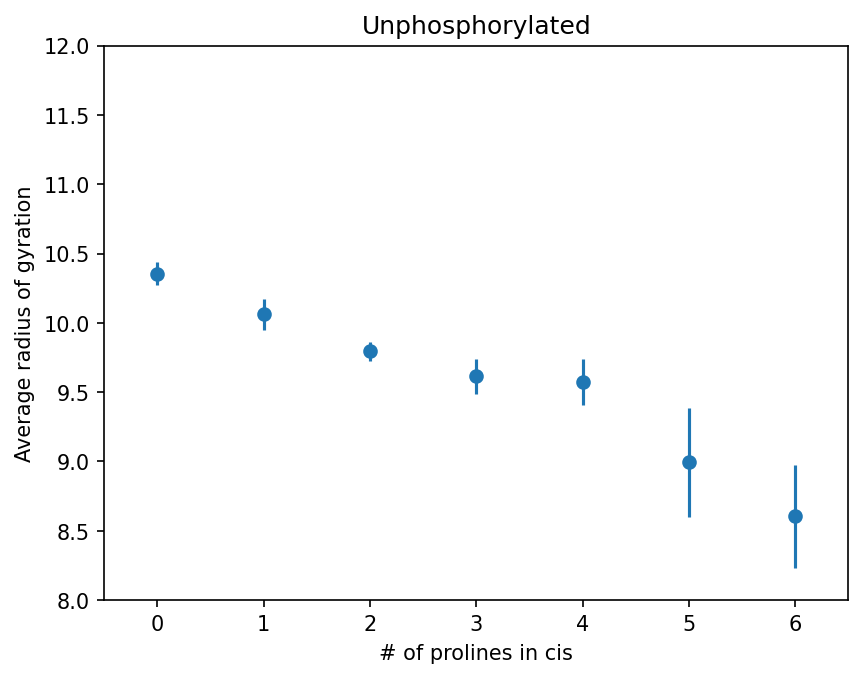

In [73]:
x_rename = np.arange(0,7)

plt.figure()
cis_radgyr_final.loc['mean'].plot(marker='o', ls='None', yerr=cis_radgyr_final.loc['sem'])
plt.ylim(8, 12)
plt.xlim(-0.5, 6.5)
plt.xticks(range(len(x_rename)), x_rename)
plt.xlabel('# of prolines in cis')
plt.ylabel('Average radius of gyration')
plt.title('Unphosphorylated')
plt.show()

In [ ]:
plt.figure()
p_cis_radgyr_final.loc['mean'].plot(marker='o', ls='None', yerr=p_cis_radgyr_final.loc['sem'])
plt.ylim(8, 12)
plt.xlim(-0.5, 6.5)
plt.xticks(range(len(x_rename)), x_rename)
plt.xlabel('# of prolines in cis')
plt.ylabel('Average radius of gyration')
plt.title('Phosphorylated')
plt.show()